# Generation of disentangled matrix on visiumHD CRC data P2

## Import libraries

In [1]:
import spatialdata as sd
import squidpy as sq

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/importlib/__init__.py:126: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)
/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd

In [3]:
from sklearn.decomposition import PCA

In [4]:
import rapids_singlecell as rsc

In [5]:
import os, sys
import pickle
import torch
from scipy.sparse import issparse
import gc
from pprint import pprint
from tqdm.autonotebook import tqdm

In [6]:
import mintflow
import mintflow.interface.perturbation.module_gen_micsizefactor
import mintflow.interface.perturbation.module_gen_stdata

## Paths

In [7]:
path_output_files = "/nfs/team361/ms83/data/CRC/visiumHD_mintflow/Outputs_nb1_P2_annealing/"

In [8]:
path_adata = '/nfs/team361/ms83/data/CRC/visiumHD_mintflow/raw_data/adata_sc_P2_rawformintflow_7K_svg.h5ad'

## Select the best checkpoint

In [9]:
df_toinspect = pd.read_pickle(
    os.path.join(path_output_files, 'df_evaluation_result_epoch_{}.pkl'.format(10))
)
# TODO:MODIFY: change `10` to the checkpoint index that you want to inspect

2026-02-04 13:06:31 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 13:06:31 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 13:06:31 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='training_epoch', ylabel='fraction_assigned_to_Xmic'>

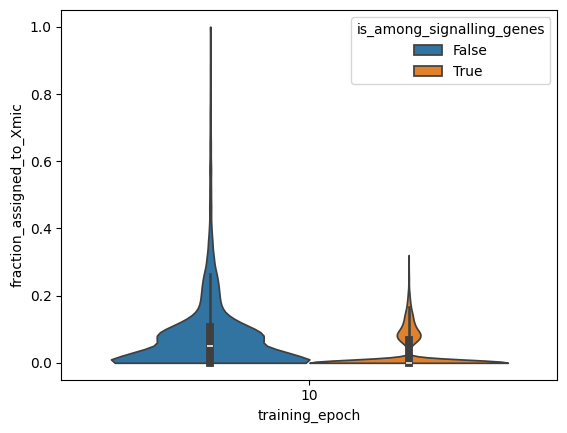

In [10]:
sns.violinplot(
    data=df_toinspect[
        df_toinspect['read_count'] > 30.0
    ],
    x='training_epoch',
    y="fraction_assigned_to_Xmic",
    hue="is_among_signalling_genes",
    cut=0
)

2026-02-04 13:06:32 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 13:06:32 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='training_epoch', ylabel='fraction_assigned_to_Xmic'>

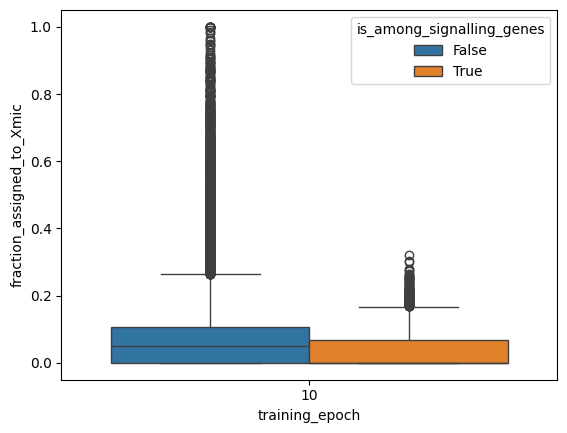

In [11]:
sns.boxplot(
    data=df_toinspect[
        df_toinspect['read_count'] > 30.0
    ],
    x='training_epoch',
    y="fraction_assigned_to_Xmic",
    hue="is_among_signalling_genes"
)

## Load the predictions checkpoint

In [12]:
index_selected_checkpoint = 10
# TODO:MODIFY: the index of the best (or a good) checkpoint that you selected. 

In [13]:
with open(os.path.join(path_output_files, "predictions_epoch_{}.pkl".format(index_selected_checkpoint)), 'rb') as f:
    predictions_selected_checkpoint = pickle.load(f)

## Load adata and compute microenvironment activity score

In [14]:
Xint = predictions_selected_checkpoint['TissueSection 0 (zero-based)']['MintFlow_Xint']
Xmic = predictions_selected_checkpoint['TissueSection 0 (zero-based)']['MintFlow_Xmic']

In [15]:
MintFlow_microenvironment_signalling_score = Xmic.sum(1) / (Xint+Xmic).sum(1)

In [16]:
MintFlow_microenvironment_signalling_score

matrix([[0.5198747 ],
        [0.52181816],
        [0.46893862],
        ...,
        [0.5033856 ],
        [0.49871147],
        [0.51120114]], shape=(322327, 1), dtype=float32)

In [17]:
adata = sc.read_h5ad(
    path_adata
)

In [18]:
adata.obs["MintFlow_microenv_score"] = MintFlow_microenvironment_signalling_score

In [19]:
adata.obs

,tissue,X,Y,DeconvolutionClass,DeconvolutionLabel1,DeconvolutionLabel2,Periphery,UnsupervisedL1,UnsupervisedL2,MacrophageSubtype,GobletSubcluster,patient,patient_id,MintFlow_microenv_score
s_008um_00301_00321-1,1,399.300118,-109.234905,singlet,Endothelial,Tumor III,50 micron,Endothelial,Endothelial-0,NaN,NaN,P2,P2,0.519875
s_008um_00526_00291-1,1,392.989875,-56.746758,singlet,Tumor III,Adipocyte,Tumor,Tumor,Tumor-0,NaN,NaN,P2,P2,0.521818
s_008um_00052_00559-1,1,453.974867,-167.954429,singlet,Goblet,Enterocyte,Tissue,Intestinal Epithelial,IntestinalEpithelial-0,NaN,Goblet-2,P2,P2,0.468939
s_008um_00504_00410-1,1,420.631613,-62.231655,singlet,Tumor III,Adipocyte,Tumor,Tumor,Tumor-0,NaN,NaN,P2,P2,0.528891
s_008um_00447_00253-1,1,383.905262,-75.027717,singlet,Tumor III,cDC I,Tumor,Tumor,Tumor-0,NaN,NaN,P2,P2,0.513625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00413_00460-1,1,432.001512,-83.575698,singlet,Endothelial,Proliferating Fibroblast,Tissue,Endothelial,Endothelial-0,NaN,NaN,P2,P2,0.493704
s_008um_00536_00521-1,1,446.573665,-55.117094,singlet,Tumor III,Adipocyte,Tumor,Tumor,Tumor-0,NaN,NaN,P2,P2,0.522969
s_008um_00131_00787-1,1,507.308736,-150.252151,singlet,Tumor III,Adipocyte,Tumor,Tumor,Tumor-0,NaN,NaN,P2,P2,0.503386
s_008um_00252_00421-1,1,422.438098,-120.951649,singlet,Pericytes,Proliferating Fibroblast,Tissue,Fibroblast,Fibroblast-1,NaN,NaN,P2,P2,0.498711


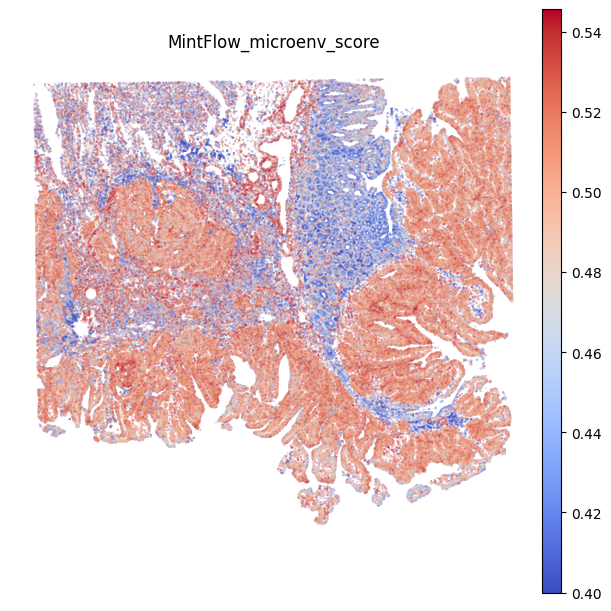

In [47]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "MintFlow_microenv_score",    
    ],
    cmap='coolwarm',
    wspace=0.4,
    size=0.02,
    figsize=(6, 6),
    vmin=np.percentile(adata.obs['MintFlow_microenv_score'], 5),
    vmax=np.percentile(adata.obs['MintFlow_microenv_score'], 95),
    frameon=False
)

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


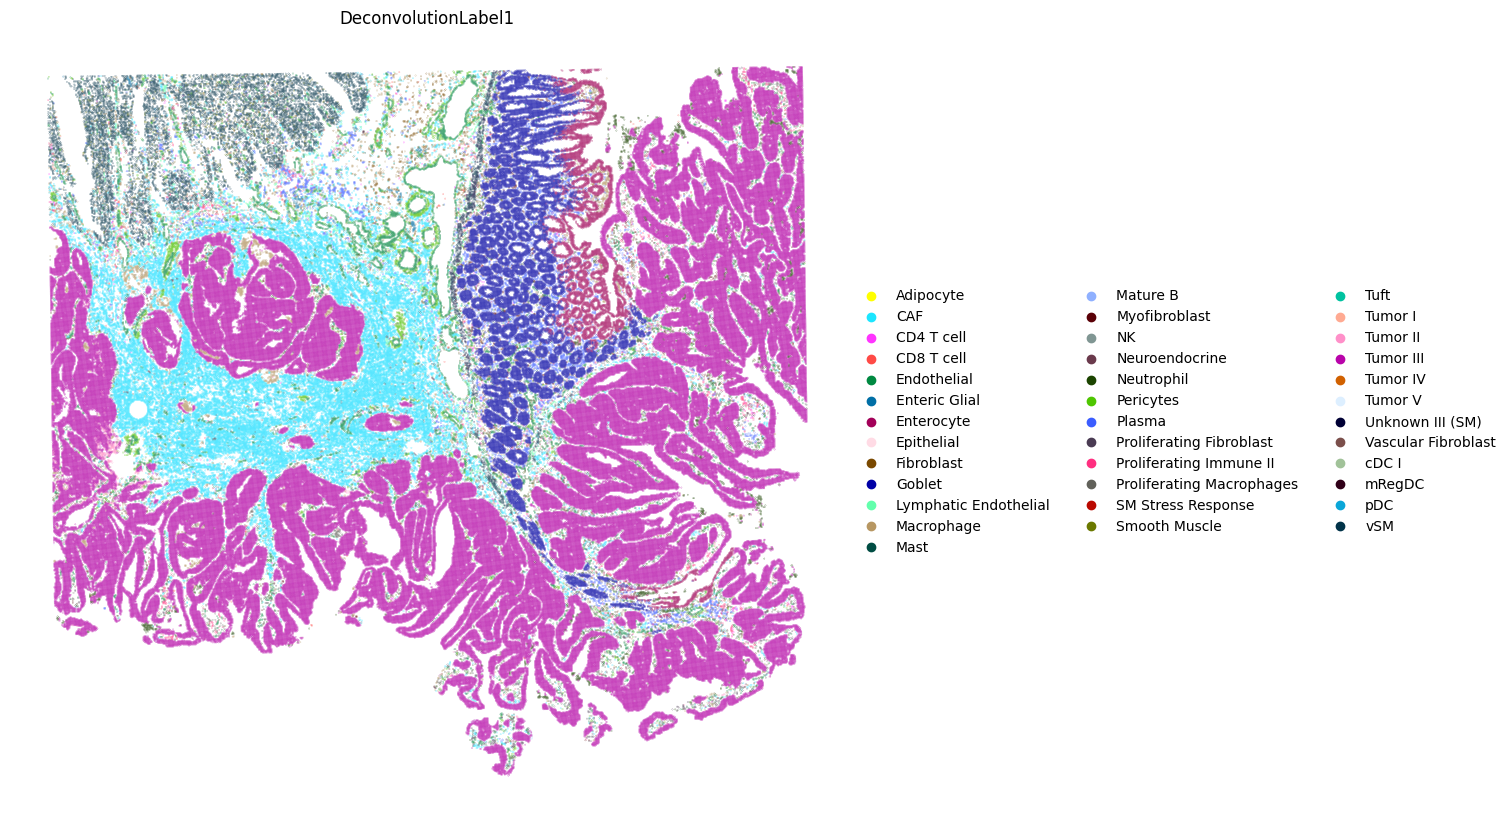

In [48]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "DeconvolutionLabel1",    
    ],
    wspace=0.4,
    size=0.02,
    figsize=(15, 15),
    frameon=False
)

## Load Mintflow model checkpoint

In [22]:
path_checkpoint = '/nfs/team361/ms83/data/CRC/visiumHD_mintflow/Outputs_nb1_P2_annealing/checkpoint_epoch_10.pt'  

In [23]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [24]:
checkpoint_mintflow = torch.load(
    path_checkpoint,
    map_location='cpu',
    weights_only=False
)
checkpoint_mintflow['model'].to(device)
print("Loaded the checkpoint.")

Loaded the checkpoint.


In [25]:
import pickle
with open('/nfs/team361/ms83/data/CRC/visiumHD_mintflow/Outputs_nb1_P2_annealing/predictions_epoch_10.pkl', 'rb') as f:
   dict_predictions = pickle.load(f)

In [26]:
dict_predictions.keys()

dict_keys(['TissueSection 0 (zero-based)'])

In [27]:
dict_predictions['TissueSection 0 (zero-based)']

{'MintFlow_Xint': <Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 62907285 stored elements and shape (322327, 7000)>,
 'MintFlow_Xmic': <Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 128704927 stored elements and shape (322327, 7000)>,
 'MintFlow_Xbar_int': array([[0.54893   , 0.        , 0.        , ..., 0.        , 0.5799753 ,
         0.        ],
        [0.53736734, 0.        , 0.        , ..., 0.        , 0.6011418 ,
         0.        ],
        [0.54107106, 0.        , 0.        , ..., 0.        , 0.5994783 ,
         0.        ],
        ...,
        [0.53783053, 0.        , 0.        , ..., 0.        , 0.5949194 ,
         0.        ],
        [0.5333271 , 0.        , 0.        , ..., 0.        , 0.60617197,
         0.        ],
        [0.53111243, 0.        , 0.        , ..., 0.        , 0.5967932 ,
         0.        ]], shape=(322327, 100), dtype=float32),
 'MintFlow_Xbar_mic': array([[0.        , 0.32498708, 1.0830736 , ..., 0.23582162, 0.

In [28]:
checkpoint_mintflow.keys()

dict_keys(['model', 'data_mintflow', 'dict_all4_configs'])

In [29]:
checkpoint_mintflow['data_mintflow']

{'train_list_tissue_section': <mintflow.utils_multislice.ListSlice at 0x14a9d3f05f10>,
 'evaluation_list_tissue_section': <mintflow.utils_multislice.ListSlice at 0x14a92522e1d0>,
 'maxsize_subgraph': 14656,
 'dict_slideID_to_maxnumcentralnodes': {'1': 2441.0},
 'dict_slideID_to_worsecasebatchsize': {'1': 14656},
 'dict_sliceID_to_pygdltrain_num_neighbours': {'1': [5]}}

In [30]:
checkpoint_mintflow['data_mintflow']['train_list_tissue_section'].list_slice[0].adata

AnnData object with n_obs × n_vars = 322327 × 7000
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id', 'inflow_CT', 'inflow_BatchID'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'Periphery_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'inflow_CT_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [31]:
adata = checkpoint_mintflow['data_mintflow']['train_list_tissue_section'].list_slice[0].adata.copy()

In [32]:
dict_predictions['TissueSection 0 (zero-based)'].keys()

dict_keys(['MintFlow_Xint', 'MintFlow_Xmic', 'MintFlow_Xbar_int', 'MintFlow_Xbar_mic', 'MintFlow_S_in', 'MintFlow_S_out', 'MintFlow_Z', 'MintFlow_Xint (before_sc_pp_normalize_total)', 'MintFlow_Xmic (before_sc_pp_normalize_total)'])

In [33]:
for k in dict_predictions['TissueSection 0 (zero-based)'].keys():
    adata.obsm[k] = dict_predictions['TissueSection 0 (zero-based)'][k]

In [34]:
adata

AnnData object with n_obs × n_vars = 322327 × 7000
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id', 'inflow_CT', 'inflow_BatchID'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'Periphery_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'inflow_CT_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'MintFlow_Xint', 'MintFlow_Xmic', 'MintFlow_Xbar_int', 'MintFlow_Xbar_mic', 'MintFlow_S_in', 'MintFlow_S_out', 'MintFlow_Z', 'MintFlow_Xint (before_sc_pp_normalize_total)', 'MintFlow_Xmic (before_sc_pp_normalize_total)'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [35]:
adata.obs["MintFlow_microenv_score"] = MintFlow_microenvironment_signalling_score

## Perform PCA, nearest neighbors and UMAP based on X bar intrinsic

In [36]:
pca = PCA(n_components=50, svd_solver="arpack")
X_pca_barint = pca.fit_transform(adata.obsm["MintFlow_Xbar_int"])

adata.obsm["X_PCA_barint"] = X_pca_barint
adata.uns["X_PCA_barint"] = {
    'variance': pca.explained_variance_,
    'variance_ratio': pca.explained_variance_ratio_
}

rsc.pp.neighbors(adata, use_rep="X_PCA_barint", key_added="neighbors_barint")
rsc.tl.umap(adata, neighbors_key="neighbors_barint", key_added="X_UMAP_barint")

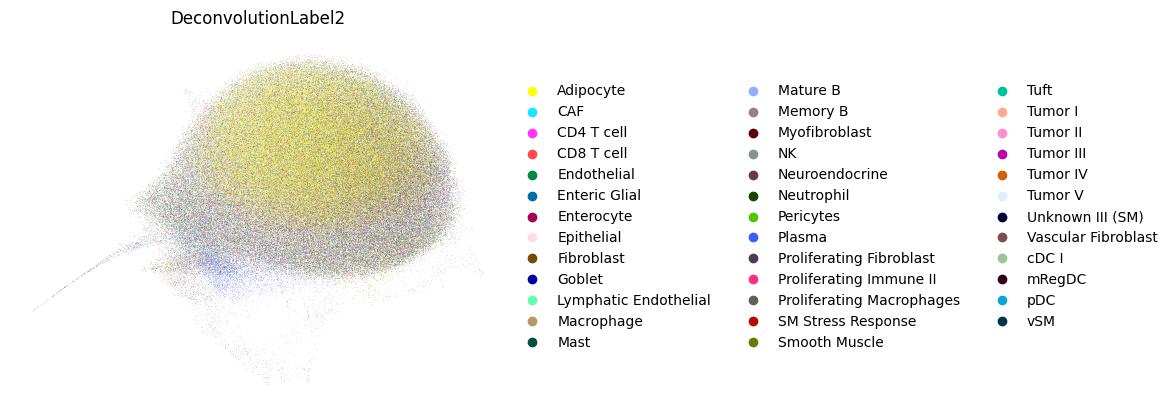

In [37]:
sc.pl.embedding(
    adata,
    color='DeconvolutionLabel2',
    basis="X_UMAP_barint",
    frameon=False
)

## Perform PCA, nearest neighbors and UMAP based on X bar spatial

In [38]:
pca = PCA(n_components=50, svd_solver="arpack")
X_pca_barint = pca.fit_transform(adata.obsm["MintFlow_Xbar_mic"])

adata.obsm["X_PCA_barmic"] = X_pca_barint
adata.uns["X_PCA_barmic"] = {
    'variance': pca.explained_variance_,
    'variance_ratio': pca.explained_variance_ratio_
}

rsc.pp.neighbors(adata, use_rep="X_PCA_barmic", key_added="neighbors_barmic")
rsc.tl.umap(adata, neighbors_key="neighbors_barmic", key_added="X_UMAP_barmic")

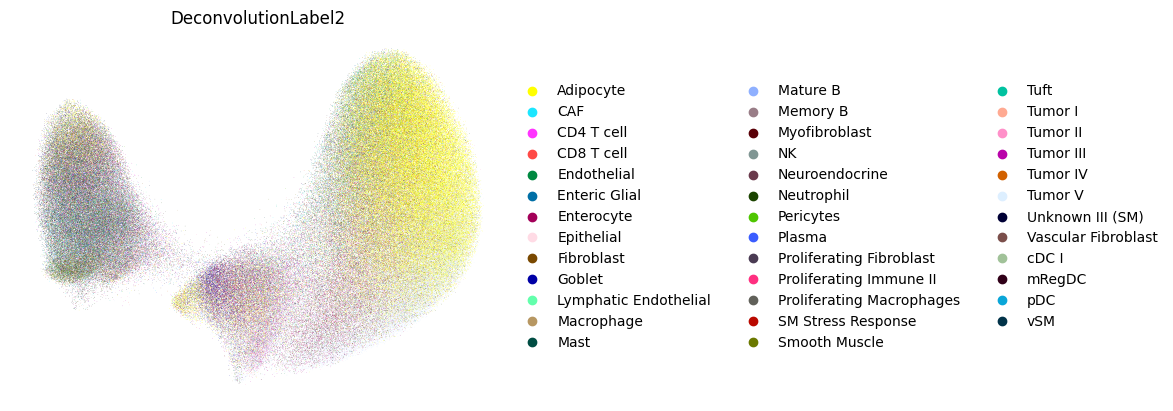

In [39]:
sc.pl.embedding(
    adata,
    color='DeconvolutionLabel2',
    basis="X_UMAP_barmic",
    frameon=False
)

## Perform PCA, nearest neighbors and UMAP based on X intrinsic

In [40]:
pca = PCA(n_components=50, svd_solver="arpack")
X_pca_barint = pca.fit_transform(adata.obsm["MintFlow_Xint"])

adata.obsm["X_PCA_int"] = X_pca_barint
adata.uns["X_PCA_int"] = {
    'variance': pca.explained_variance_,
    'variance_ratio': pca.explained_variance_ratio_
}

rsc.pp.neighbors(adata, use_rep="X_PCA_int", key_added="neighbors_int")
rsc.tl.umap(adata, neighbors_key="neighbors_int", key_added="X_UMAP_int")

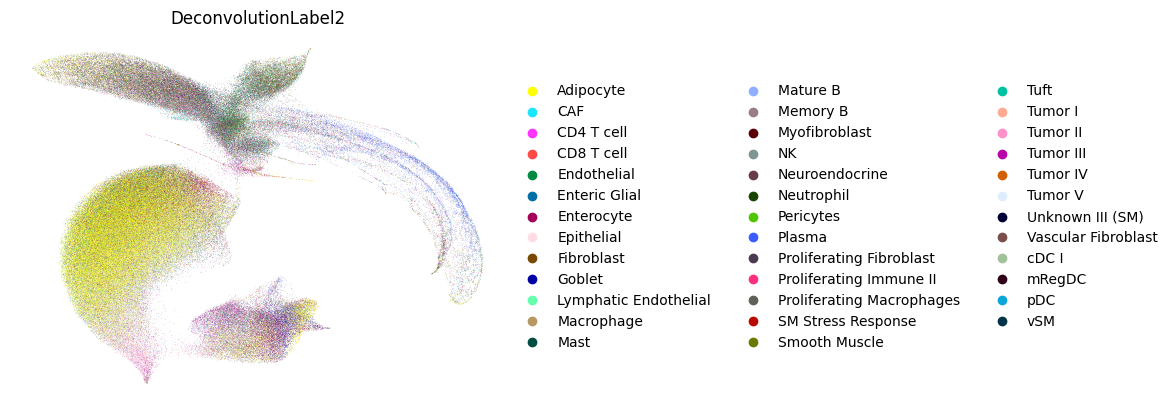

In [41]:
sc.pl.embedding(
    adata,
    color='DeconvolutionLabel2',
    basis="X_UMAP_int",
    frameon=False
)

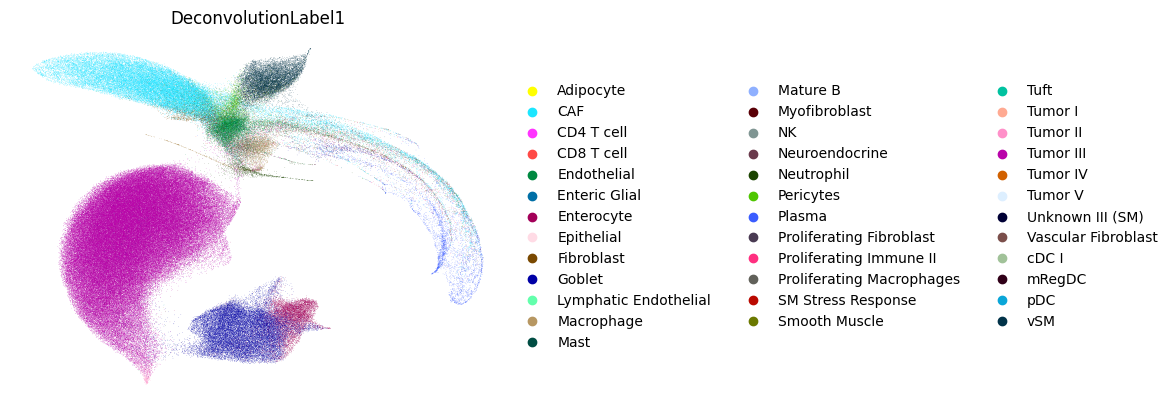

In [42]:
sc.pl.embedding(
    adata,
    color='DeconvolutionLabel1',
    basis="X_UMAP_int",
    frameon=False
)

## Perform PCA, nearest neighbors and UMAP based on X spatial

In [43]:
pca = PCA(n_components=50, svd_solver="arpack")
X_pca_barint = pca.fit_transform(adata.obsm["MintFlow_Xmic"])

adata.obsm["X_PCA_mic"] = X_pca_barint
adata.uns["X_PCA_mic"] = {
    'variance': pca.explained_variance_,
    'variance_ratio': pca.explained_variance_ratio_
}

rsc.pp.neighbors(adata, use_rep="X_PCA_mic", key_added="neighbors_mic")
rsc.tl.umap(adata, neighbors_key="neighbors_mic", key_added="X_UMAP_mic")

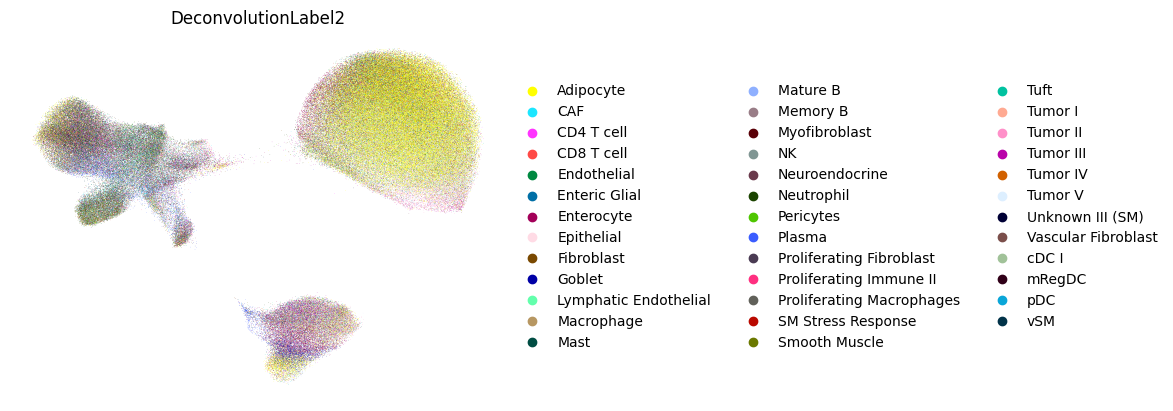

In [44]:
sc.pl.embedding(
    adata,
    color='DeconvolutionLabel2',
    basis="X_UMAP_mic",
    frameon=False
)

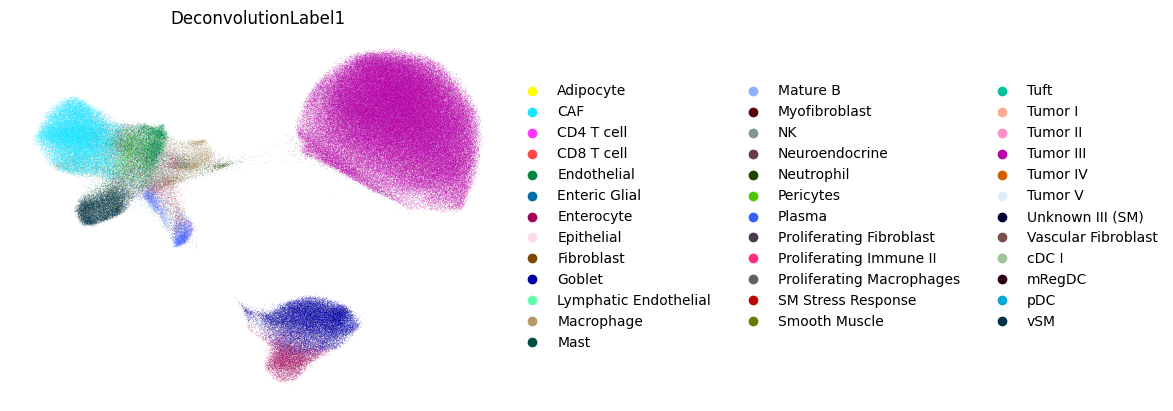

In [45]:
sc.pl.embedding(
    adata,
    color='DeconvolutionLabel1',
    basis="X_UMAP_mic",
    frameon=False
)

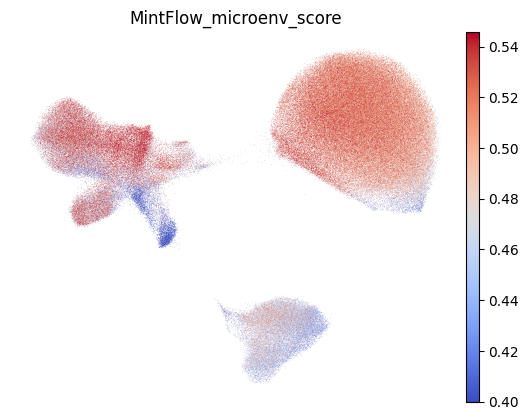

In [46]:
sc.pl.embedding(
    adata,
    color='MintFlow_microenv_score',
    basis="X_UMAP_mic",
    cmap='coolwarm',
    frameon=False,
    vmin=np.percentile(adata.obs['MintFlow_microenv_score'], 5),
    vmax=np.percentile(adata.obs['MintFlow_microenv_score'], 95)    
)

In [57]:
adata.write_h5ad(path_output_files + 'adata_P2_mic_score.h5ad')

In [49]:
adata

AnnData object with n_obs × n_vars = 322327 × 7000
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id', 'inflow_CT', 'inflow_BatchID', 'MintFlow_microenv_score'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'Periphery_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'inflow_CT_colors', 'X_PCA_barint', 'neighbors_barint', 'X_UMAP_barint', 'X_PCA_barmic', 'neighbors_barmic', 'X_UMAP_barmic', 'X_PCA_int', 'neighbors_int', 'X_UMAP_int', 'X_PCA_mic', 'neighbors_mic', 'X_UMAP_mic'
    obsm: 'X_pca', 'X_umap', 'spatial', 'MintFlow_Xint', 'MintFlow_Xmic', 'MintFlow_Xbar_int', 'MintFlow_Xbar_mic', 'MintFlow_S_in', 'MintFlow_S_out', 'MintFlow_Z', 'MintFlow_Xint (

In [50]:
tls_signature_crc = [
    'ITGAM',  # CD11
    'MS4A1',   # CD20, B cells
    'CD3D',    # T cells
    'CD79A',   # B cells
    'CR2',   # CD21 
    'FCER2',    # CD23
    'CXCR5',    # Follicular helper T cells
    'NTAN1', # PNAD, High endothelial venules (HEVs)
    'CCL21', # chemokine
    'CXCL13', # Chemokine
    'LYVE1' # lymphaic endothelium
]

sc.tl.score_genes(adata, tls_signature_crc, score_name='TLS_crc')

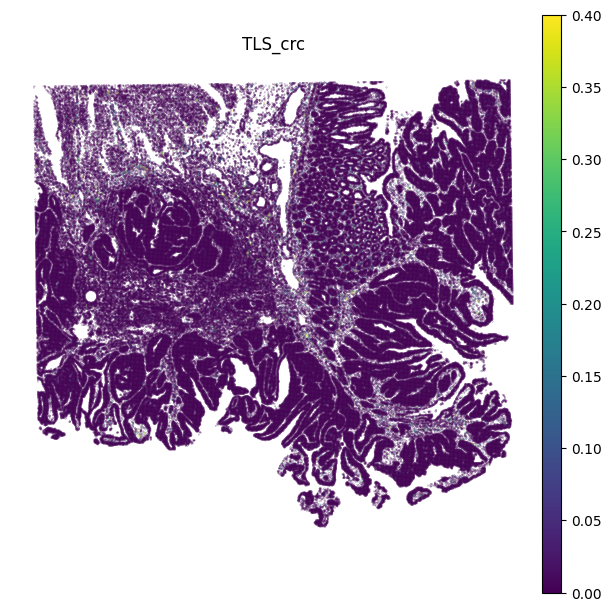

In [51]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=["TLS_crc"],
    #groups=["CD8 T cell"],   # cell type(s) of interest
    wspace=0.4,
    size=0.02,
    figsize=(6, 6),
    #cmap='coolwarm',
    vmin=0,
    vmax=0.4,
    frameon=False
)

In [52]:
tls_signature_minimal = [
    'CXCL13',  # Most specific TLS marker
    'MS4A1',   # CD20, B cells
    'CD3D',    # T cells
    'CD79A',   # B cells
    'CCL21',   # TLS chemokine
    'BCL6',    # Germinal centers
    'CXCR5'    # Follicular helper T cells
]

sc.tl.score_genes(adata, tls_signature_minimal, score_name='TLS_general')

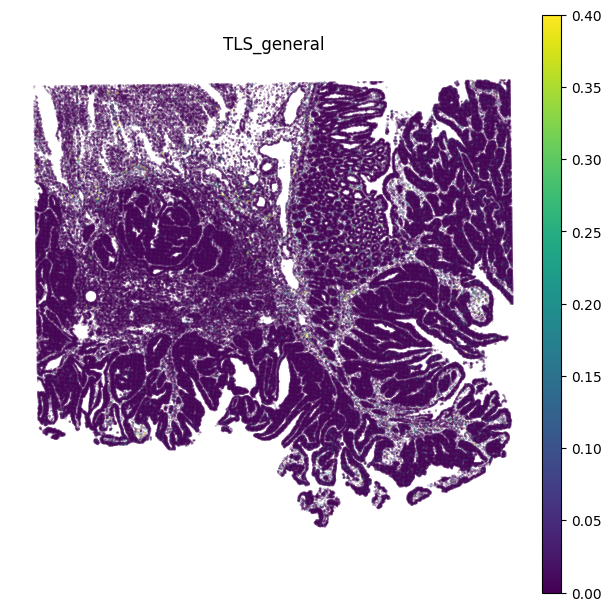

In [53]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=["TLS_general"],
    #groups=["CD8 T cell"],   # cell type(s) of interest
    wspace=0.4,
    size=0.02,
    figsize=(6, 6),
    #cmap='coolwarm',
    vmin=0,
    vmax=0.4,
    frameon=False
)